Question 1 :
A company wants to analyze customer satisfaction survey data. How can Data Science concepts help to clean and analyze this data?


In [2]:
import pandas as pd
import numpy as np
data={ 'CustomerID': [1, 2, 3, 4, 5, 5, 6, 7, 8, 9],
    'Satisfaction': [8, 7, np.nan, 9, 6, 6, 10, 4, 5, 7]
}
data=pd.DataFrame(data)
data.isnull().sum()
median=data['Satisfaction'].median()
data['Satisfaction'].fillna(median,inplace=True)

C:\Users\jerli\AppData\Local\Temp\ipykernel_21364\381806785.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Satisfaction'].fillna(median,inplace=True)


In [5]:
data.mode()

,CustomerID,Satisfaction
0,5,7.0


In [12]:
data.drop_duplicates('CustomerID',inplace=True)

In [13]:
data

,CustomerID,Satisfaction
0,1,8.0
1,2,7.0
2,3,7.0
3,4,9.0
4,5,6.0
6,6,10.0
7,7,4.0
8,8,5.0
9,9,7.0


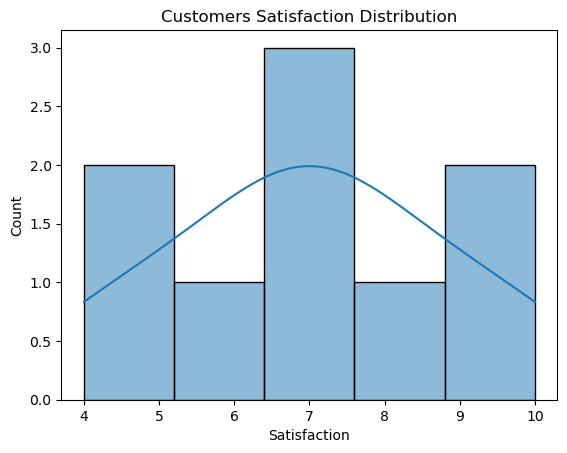

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data['Satisfaction'],kde=True)
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.title("Customers Satisfaction Distribution")
plt.show()

In [16]:
#the peak is at 7 , so many customers have given 7

Question 2 :
 A retail store has recorded monthly sales data for its products. How can Data Science concepts be applied to understand sales performance?
SampleDataset:
'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
 'Sales': [1500, 1700, 1600, 1800, 2200, 2100]


In [31]:
sale={'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], 'Sales': [1500, 1700, 1600, 1800, 2200, 2100]}
sales=pd.DataFrame(sale)
q1,q3=np.percentile(sales['Sales'],[25,75])
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)
print("Less Outlier:",lower_bound)
print("Greater Outlier:",upper_bound)
less_outlier=[i for i in sales['Sales'] if i>upper_bound]
print("Outliers:",less_outlier)

Less Outlier: 1025.0
Greater Outlier: 2625.0
Outliers: []


Text(0.5, 1.0, 'Bar Plot of the sales')

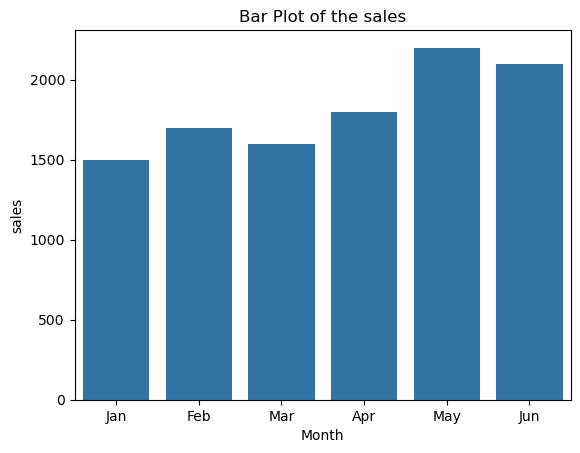

In [33]:
sns.barplot(sales,x='Month',y='Sales')
plt.xlabel('Month')
plt.ylabel('sales')
plt.title("Bar Plot of the sales")

Question 3:
A hospital conducted a study to check the effectiveness of a new medical test. How can Data Science concepts be used to validate its results?
SampleDataset:
group_a = [110, 115, 108, 102, 107]
group_b = [120, 125, 130, 122, 128]
Expected Output:
T-Statistic: -5.92, P-Value: 0.0004
Reject Null Hypothesis: The test is effective.



In [36]:
group_a = [110, 115, 108, 102, 107]
group_b = [120, 125, 130, 122, 128]
from scipy.stats import ttest_ind
t_stats,p_value=ttest_ind(group_a,group_b)
h0="The test is not effective"
h1="The test is effective"
print("P-Vale:",p_value)
print("T-satatistic:",t_stats)
if p_value<0.05:
    print("Rject Null Hypothesis:",h1)
else:
    print("Reject Alternate Hypothesis",h0)

P-Vale: 0.0003532844625064416
T-satatistic: -5.921023912553299
Rject Null Hypothesis: The test is effective


Question 4:
 A company wants to evaluate employee performance using various metrics. How can Data Science concepts be applied?
Sample Dataset:
    'Department': ['HR', 'IT', 'Sales', 'IT', 'HR', 'Sales', np.nan, 'HR', 'Sales', 'IT'],
    'Experience (Years)': [1.0, 3.0, 5.0, np.nan, 10.0, 2.0, 8.0, 4.0, np.nan, 9.0],
    'Projects Completed': [2.0, 5.0, np.nan, 10.0, 12.0, 3.0, 9.0, np.nan, 14.0, 11.0],
    'Performance Rating': [3.0, np.nan, 7.0, 8.0, 9.0, 4.0, 8.0, 7.0, 10.0, np.nan]


In [41]:
dataset={ 'Department': ['HR', 'IT', 'Sales', 'IT', 'HR', 'Sales', np.nan, 'HR', 'Sales', 'IT'],
    'Experience (Years)': [1.0, 3.0, 5.0, np.nan, 10.0, 2.0, 8.0, 4.0, np.nan, 9.0],
    'Projects Completed': [2.0, 5.0, np.nan, 10.0, 12.0, 3.0, 9.0, np.nan, 14.0, 11.0],
    'Performance Rating': [3.0, np.nan, 7.0, 8.0, 9.0, 4.0, 8.0, 7.0, 10.0, np.nan]}
dataset=pd.DataFrame(dataset)
dataset.isnull().sum()

Department            1
Experience (Years)    2
Projects Completed    2
Performance Rating    2
dtype: int64

In [60]:
dataset['Experience (Years)'].fillna(dataset['Experience (Years)'].median(),inplace=True)
dataset['Projects Completed'].fillna(dataset['Projects Completed'].median(),inplace=True)
dataset['Performance Rating'].fillna(dataset['Performance Rating'].median(),inplace=True)
dataset['Department'].replace(np.nan,dataset['Department'].value_counts().idxmax(),inplace=True)

C:\Users\jerli\AppData\Local\Temp\ipykernel_21364\4258834779.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Experience (Years)'].fillna(dataset['Experience (Years)'].median(),inplace=True)
C:\Users\jerli\AppData\Local\Temp\ipykernel_21364\4258834779.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

In [61]:
dataset.isnull().sum()

Department            0
Experience (Years)    0
Projects Completed    0
Performance Rating    0
dtype: int64

In [62]:
dataset

,Department,Experience (Years),Projects Completed,Performance Rating
0,HR,1.0,2.0,3.0
1,IT,3.0,5.0,7.5
2,Sales,5.0,9.5,7.0
3,IT,4.5,10.0,8.0
4,HR,10.0,12.0,9.0
5,Sales,2.0,3.0,4.0
6,HR,8.0,9.0,8.0
7,HR,4.0,9.5,7.0
8,Sales,4.5,14.0,10.0
9,IT,9.0,11.0,7.5


In [63]:
dataset.describe()

,Experience (Years),Projects Completed,Performance Rating
count,10.000000,10.00000,10.0000
mean,5.100000,8.50000,7.1000
std,2.988868,3.91578,2.1187
min,1.000000,2.00000,3.0000
25%,3.250000,6.00000,7.0000
50%,4.500000,9.50000,7.5000
75%,7.250000,10.75000,8.0000
max,10.000000,14.00000,10.0000


<Axes: >

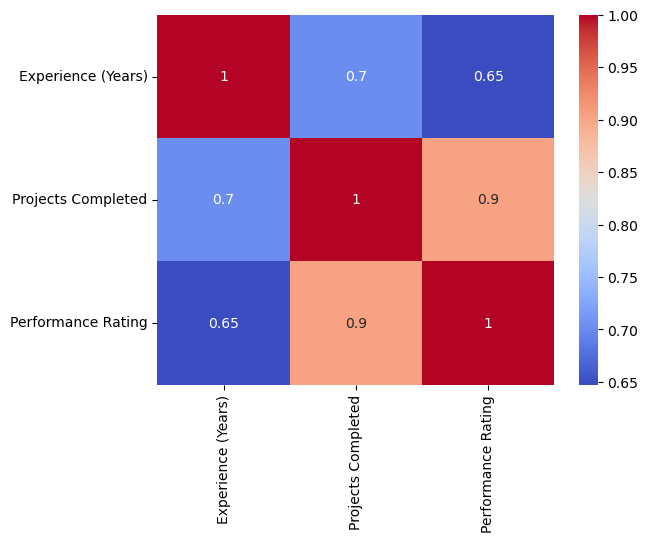

In [71]:
correlation_matrix=dataset[['Experience (Years)','Projects Completed','Performance Rating']].corr()
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True)

<Figure size 1000x400 with 0 Axes>

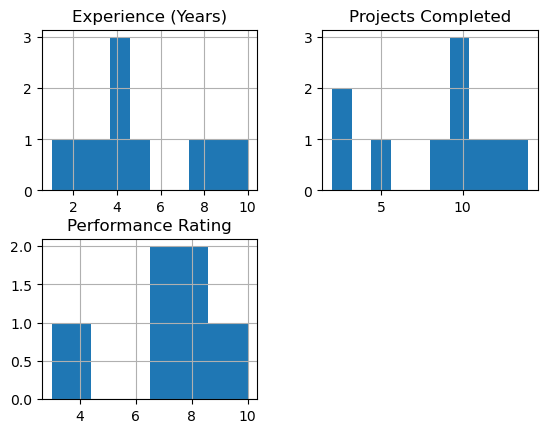

<Figure size 1000x400 with 0 Axes>

In [77]:
dataset[['Experience (Years)','Projects Completed','Performance Rating']].hist()
plt.figure(figsize=(10,4))
#plt.title("Histogram")

Text(0.5, 1.0, 'Box Plot')

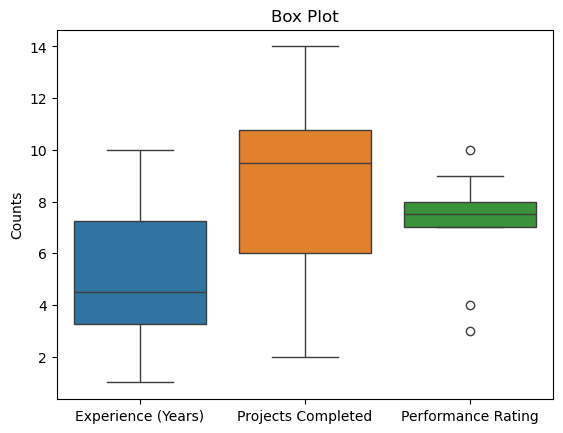

In [80]:
sns.boxplot(dataset)
plt.ylabel("Counts")
plt.title("Box Plot")

Text(0.5, 1.0, 'Scatter Plot For Experience vs Performance')

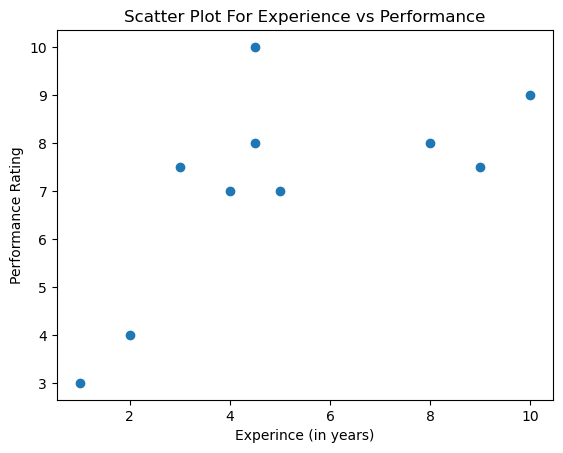

In [85]:
plt.scatter(x=dataset['Experience (Years)'],y=dataset['Performance Rating'])
plt.xlabel("Experince (in years)")
plt.ylabel("Performance Rating")
plt.title("Scatter Plot For Experience vs Performance")

In [88]:
dataset["Department"].value_counts()

Department
HR       4
IT       3
Sales    3
Name: count, dtype: int64

In [91]:
hr=dataset[dataset["Department"]=='HR']
it=dataset[dataset["Department"]=='IT']
sales=dataset[dataset["Department"]=='Sales']

In [96]:
hr

,Department,Experience (Years),Projects Completed,Performance Rating
0,HR,1.0,2.0,3.0
4,HR,10.0,12.0,9.0
6,HR,8.0,9.0,8.0
7,HR,4.0,9.5,7.0


<Axes: >

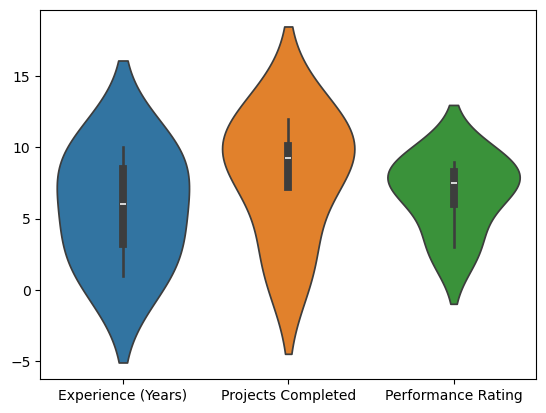

In [95]:
sns.violinplot(hr)

<Axes: xlabel='Department', ylabel='Performance Rating'>

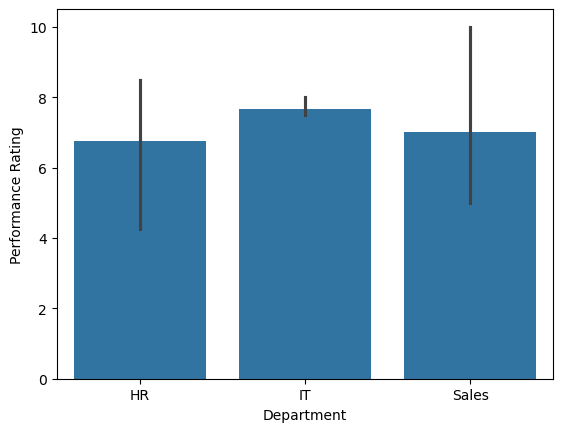

In [97]:
sns.barplot(x=dataset["Department"],y=dataset["Performance Rating"])

<Axes: xlabel='Department', ylabel='Projects Completed'>

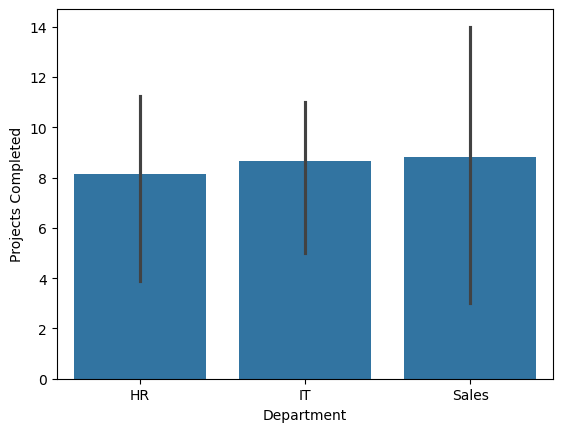

In [102]:
sns.barplot(x=dataset["Department"],y=dataset["Projects Completed"])